In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow_decision_forests as tfdf
import pandas as pd

https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/RandomForestModel

In [2]:
dataset_df = pd.read_csv("./data/final.csv")

In [3]:
training = dataset_df[dataset_df["year"] < 2021]
test = dataset_df[dataset_df["year"] >= 2021]
single = dataset_df[dataset_df["raceId"] == 1134]

In [4]:
single

,raceId,grid,position,year,date,time,circuitRef,driverRef,constructorRef,circuit_code,driver_code,constructor_code,pos_delta
2739,1134,3.0,1.0,2024,2024-07-28,15:00,spa,hamilton,mercedes,25,11,8,2.0
2740,1134,5.0,2.0,2024,2024-07-28,15:00,spa,piastri,mclaren,25,25,7,3.0
2741,1134,1.0,3.0,2024,2024-07-28,15:00,spa,leclerc,ferrari,25,18,4,-2.0
2742,1134,11.0,4.0,2024,2024-07-28,15:00,spa,max_verstappen,red_bull,25,19,11,7.0
2743,1134,4.0,5.0,2024,2024-07-28,15:00,spa,norris,mclaren,25,22,7,-1.0
2744,1134,7.0,6.0,2024,2024-07-28,15:00,spa,sainz,ferrari,25,30,4,1.0
2745,1134,2.0,7.0,2024,2024-07-28,15:00,spa,perez,red_bull,25,24,11,-5.0
2746,1134,8.0,8.0,2024,2024-07-28,15:00,spa,alonso,aston_martin,25,2,3,0.0
2747,1134,9.0,9.0,2024,2024-07-28,15:00,spa,ocon,alpine,25,23,2,0.0
2748,1134,13.0,10.0,2024,2024-07-28,15:00,spa,ricciardo,rb,25,28,10,3.0


In [5]:
predictors = ["raceId", "grid", "position", "pos_delta", "year", "date", "time", "driver_code", "constructor_code", "circuit_code"]

In [6]:
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(training[predictors], label="driver_code")
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test[predictors])
single_ds = tfdf.keras.pd_dataframe_to_tf_dataset(single[predictors])

In [7]:
model = tfdf.keras.RandomForestModel(verbose=0)

model.fit(train_ds)

[INFO 24-07-31 16:09:10.0271 CEST kernel.cc:1233] Loading model from path /var/folders/hk/ffpx1y0s2cn133v15g3yks080000gn/T/tmpnox55662/model/ with prefix 2a9a64dd297d4413
[INFO 24-07-31 16:09:10.1561 CEST decision_forest.cc:734] Model loaded with 300 root(s), 95700 node(s), and 9 input feature(s).
[INFO 24-07-31 16:09:10.1562 CEST abstract_model.cc:1344] Engine "RandomForestGeneric" built
[INFO 24-07-31 16:09:10.1562 CEST kernel.cc:1061] Use fast generic engine


In [8]:
predictions = model.predict(single_ds)

1/1 [==============================] - 0s 45ms/step


### Prediction tables:
    Rows - prediction number
    Column - driverId

In [9]:
predictions

array([[0.        , 0.00333333, 0.        , 0.        , 0.37999973,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.5199996 , 0.00333333, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.00666667, 0.01333333,
        0.        , 0.        , 0.        , 0.        , 0.02333334,
        0.        , 0.        , 0.        , 0.        , 0.01      ,
        0.01666667, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.02333334],
       [0.        , 0.01333333, 0.00666667, 0.        , 0.07666666,
        0.        , 0.        , 0.        , 0.01666667, 0.        ,
        0.04666667, 0.06333334, 0.        , 0.03      , 0.        ,
        0.00333333, 0.        , 0.        , 0.05333334, 0.00666667,
        0.        , 0.        , 0.3666664 , 0.        , 0.02      ,
        0.        , 0.        , 0.01      , 0.        , 0.        ,
        0.23333319, 0.        , 0.        , 0.00333333, 0.        ,
        0.     

In [10]:
predictions_df = pd.DataFrame(predictions[0])

In [14]:
with_names = pd.merge(single, predictions_df, left_on="driver_code", right_on=predictions_df.index)

with_names

,raceId,grid,position,year,date,time,circuitRef,driverRef,constructorRef,circuit_code,driver_code,constructor_code,pos_delta,0
0,1134,3.0,1.0,2024,2024-07-28,15:00,spa,hamilton,mercedes,25,11,8,2.0,0.520000
1,1134,5.0,2.0,2024,2024-07-28,15:00,spa,piastri,mclaren,25,25,7,3.0,0.000000
2,1134,1.0,3.0,2024,2024-07-28,15:00,spa,leclerc,ferrari,25,18,4,-2.0,0.006667
3,1134,11.0,4.0,2024,2024-07-28,15:00,spa,max_verstappen,red_bull,25,19,11,7.0,0.013333
4,1134,4.0,5.0,2024,2024-07-28,15:00,spa,norris,mclaren,25,22,7,-1.0,0.000000
5,1134,7.0,6.0,2024,2024-07-28,15:00,spa,sainz,ferrari,25,30,4,1.0,0.016667
6,1134,2.0,7.0,2024,2024-07-28,15:00,spa,perez,red_bull,25,24,11,-5.0,0.023333
7,1134,8.0,8.0,2024,2024-07-28,15:00,spa,alonso,aston_martin,25,2,3,0.0,0.000000
8,1134,9.0,9.0,2024,2024-07-28,15:00,spa,ocon,alpine,25,23,2,0.0,0.000000
9,1134,13.0,10.0,2024,2024-07-28,15:00,spa,ricciardo,rb,25,28,10,3.0,0.000000


In [15]:
model.make_inspector().evaluation()

Evaluation(num_examples=1180, accuracy=0.1423728813559322, loss=1.544972153588877, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

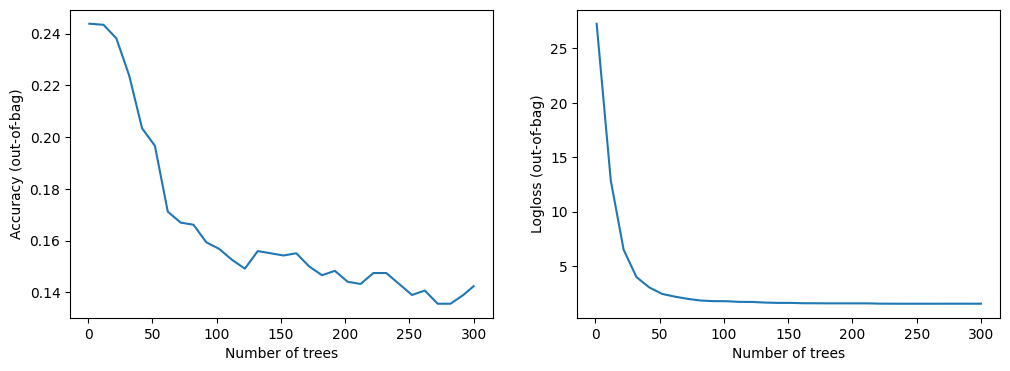

In [16]:
import matplotlib.pyplot as plt

logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")

plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")

plt.show()
